### Import


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Loading Dataset

In [2]:
df = pd.read_csv("C:/Users/adni/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

##### Approximately 1 in every 4 customers leaves the company.

### Checking Missing Values

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Check Total Charges

In [7]:
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [8]:
df["TotalCharges"].dtype

dtype('O')

### Churn Distribution Visualization

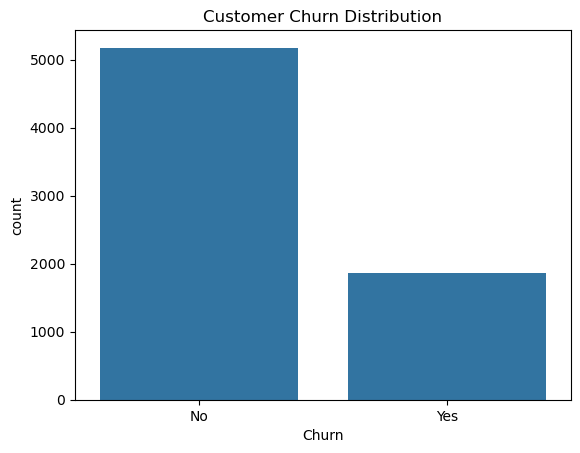

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

### Contract Vs Churn

In [10]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


### Hypothesis
##### Month-to-month customers leave more often.

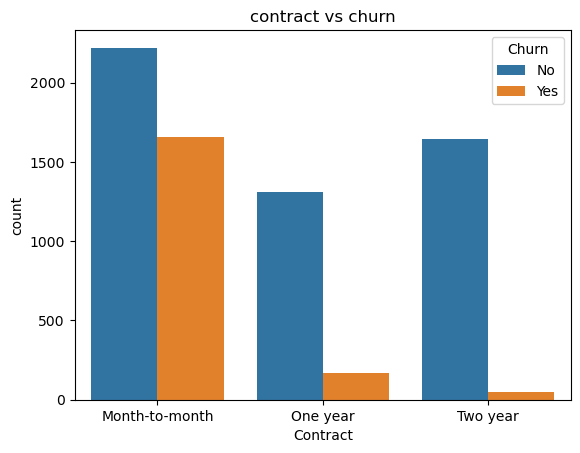

In [11]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)
plt.title("contract vs churn")
plt.show()

### Tenure Vs Churn

### Hypothesis
#### Long-term customers are less likely to leave.

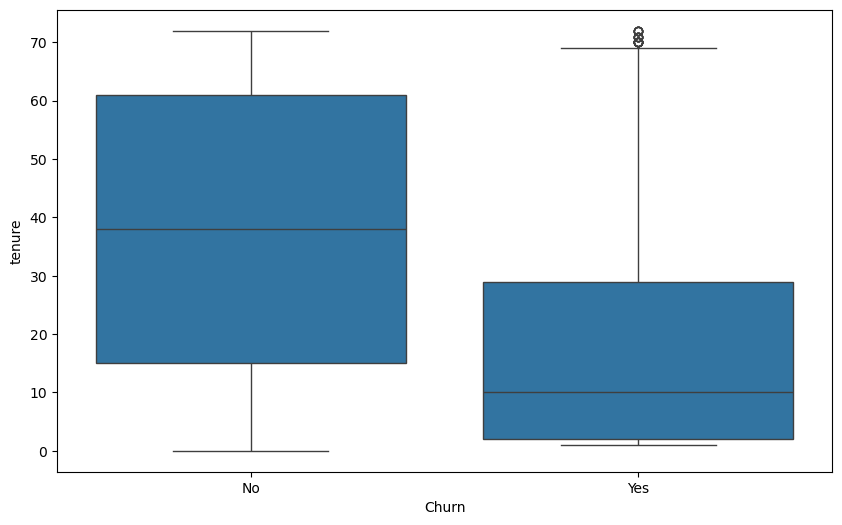

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.show()

### Monthly Charges Vs Churn

### Hypothesis
##### Higher monthly bills increase churn risk.

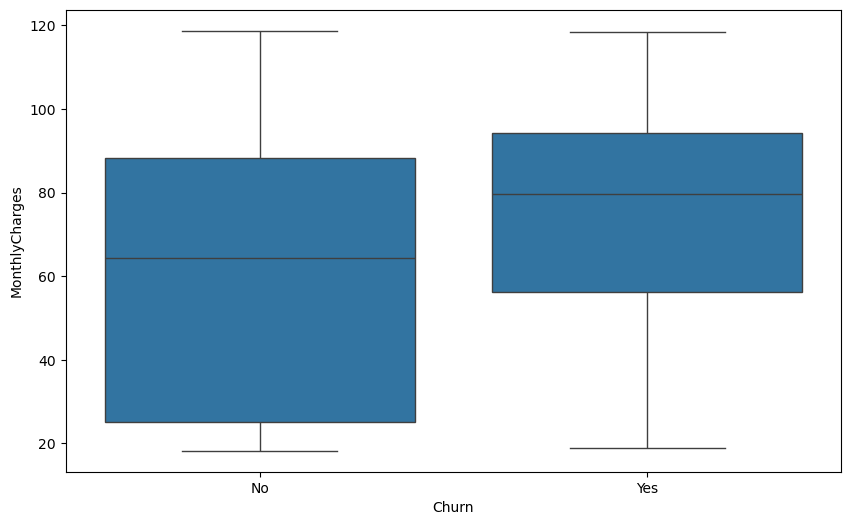

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

### Fix Total Charges

In [14]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [15]:
df["TotalCharges"].dtype

dtype('float64')

In [16]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [17]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

C:\Users\adni\AppData\Local\Temp\ipykernel_20684\575980950.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


In [18]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Dropping Customer Id

##### It has no business value

In [19]:
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

### Encoding Target Variable
##### No - 0 and Yes - 1

In [20]:
df["Churn"] = df["Churn"].map(
    {
        "No": 0,
        "Yes": 1
    }
)

In [21]:
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

### Encoding all Categorical Features

In [22]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [23]:
df_encoded.shape

(7043, 31)

### Defining Features and Target

In [24]:
X = df_encoded.drop(
    "Churn",
    axis=1
)

y = df_encoded["Churn"]

### Train_Test_Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 42)

In [26]:
X_train.shape
X_test.shape

(1409, 30)

In [27]:
X_train.shape

(5634, 30)

### Decision Tree Classifier

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
dt = DecisionTreeClassifier(
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

### Accuracy

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    dt_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.7097232079489


### Confusion Matrix

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    dt_pred
)

print(cm)

[[831 205]
 [204 169]]


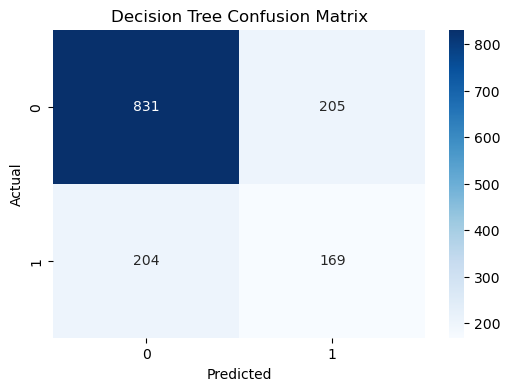

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

### Precision

In [33]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    dt_pred
)

print("Precision:", precision)

Precision: 0.45187165775401067


### Recall

In [34]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_test,
    dt_pred
)

print("Recall:", recall)

Recall: 0.45308310991957107


### F1-Score

In [35]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    dt_pred
)

print("F1:", f1)

F1: 0.4524765729585007


### Random Forest Classifier

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
rf = RandomForestClassifier (n_estimators = 100, random_state = 42)

In [38]:
rf.fit( X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
rf_pred = rf.predict(X_test)

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)

Accuracy: 0.7892122072391767
Precision: 0.6428571428571429
Recall: 0.4584450402144772
F1: 0.5352112676056338


### Confusion Matrix

In [41]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

print(cm_rf)

[[941  95]
 [202 171]]


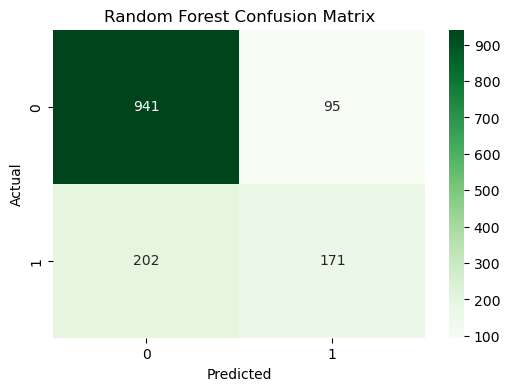

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Feature Importance

In [43]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
).head(10)

,Feature,Importance
3,TotalCharges,0.189701
1,tenure,0.175710
2,MonthlyCharges,0.172418
10,InternetService_Fiber optic,0.036053
28,PaymentMethod_Electronic check,0.035302
25,Contract_Two year,0.030435
13,OnlineSecurity_Yes,0.029238
4,gender_Male,0.027423
26,PaperlessBilling_Yes,0.025295
5,Partner_Yes,0.024209


### Install Libraries

In [50]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 3.8 MB/s eta 0:00:27
    --------------------------------------- 1.6/101.7 MB 3.8 MB/s eta 0:00:27
    --------------------------------------- 2.4/101.7 MB 3.0 MB/s eta 0:00:34
   - -------------------------------------- 3.7/101.7 MB 3.5 MB/s eta 0:00:28
   - -------------------------------------- 3.9/101.7 MB 3.4 MB/s eta 0:00:29
   - -------------------------------------- 4.7/101.7 MB 3.4 MB/s eta 0:00:29
   - -------------------------------------- 5.0/101.7 MB 3.4 MB/s eta 0:00:29
   - -------------------------------------- 5.0/101.7 MB 3.4 MB/s eta 0:00:29
   -- ------------------------------------- 7.3/101.7 MB 3.6 MB/s eta 0:00:27
   --- -------

In [51]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


### Import Models

In [52]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

### Create Models

In [53]:
dt = DecisionTreeClassifier(
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

### Train all Models

In [54]:
dt.fit(X_train, y_train)

rf.fit(X_train, y_train)

gb.fit(X_train, y_train)

xgb.fit(X_train, y_train)

lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000332 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Predictions

In [55]:
dt_pred = dt.predict(X_test)

rf_pred = rf.predict(X_test)

gb_pred = gb.predict(X_test)

xgb_pred = xgb.predict(X_test)

lgbm_pred = lgbm.predict(X_test)

### Evaluation Function

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(
    y_true,
    y_pred,
    model_name
):

    print(f"\n{model_name}")

    print(
        "Accuracy:",
        accuracy_score(y_true, y_pred)
    )

    print(
        "Precision:",
        precision_score(y_true, y_pred)
    )

    print(
        "Recall:",
        recall_score(y_true, y_pred)
    )

    print(
        "F1:",
        f1_score(y_true, y_pred)
    )

### Evaluate

In [57]:
evaluate_model(
    y_test,
    dt_pred,
    "Decision Tree"
)

evaluate_model(
    y_test,
    rf_pred,
    "Random Forest"
)

evaluate_model(
    y_test,
    gb_pred,
    "Gradient Boosting"
)

evaluate_model(
    y_test,
    xgb_pred,
    "XGBoost"
)

evaluate_model(
    y_test,
    lgbm_pred,
    "LightGBM"
)


Decision Tree
Accuracy: 0.7097232079489
Precision: 0.45187165775401067
Recall: 0.45308310991957107
F1: 0.4524765729585007

Random Forest
Accuracy: 0.7892122072391767
Precision: 0.6428571428571429
Recall: 0.4584450402144772
F1: 0.5352112676056338

Gradient Boosting
Accuracy: 0.8090844570617459
Precision: 0.6721854304635762
Recall: 0.5442359249329759
F1: 0.6014814814814815

XGBoost
Accuracy: 0.8133427963094393
Precision: 0.6845637583892618
Recall: 0.546916890080429
F1: 0.6080476900149031

LightGBM
Accuracy: 0.7984386089425124
Precision: 0.6459016393442623
Recall: 0.5281501340482574
F1: 0.5811209439528023


### Comparison Table

In [64]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM"
    ],
    
    "Accuracy": [
        0.7097232079489,
        0.7892122072391767,
        0.8090844570617459,
        0.8133427963094393,
        0.7984386089425124
    ],
    
    "Precision": [
        0.45187165775401067,
        0.6428571428571429,
        0.6721854304635762,
        0.6845637583892618,
        0.6459016393442623
    ],
    
    "Recall": [
        0.45308310991957107,
        0.4584450402144772,
        0.5442359249329759,
        0.546916890080429,
        0.5281501340482574
    ],
    
    "F1": [
        0.4524765729585007,
        0.5352112676056338,
        0.6014814814814815,
        0.6080476900149031,
        0.5811209439528023
    ]
})

results.sort_values(
    by="F1",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.709723,0.451872,0.453083,0.452477
1,Random Forest,0.789212,0.642857,0.458445,0.535211
2,Gradient Boosting,0.809084,0.672185,0.544236,0.601481
3,XGBoost,0.813343,0.684564,0.546917,0.608048
4,LightGBM,0.798439,0.645902,0.528150,0.581121


In [62]:
results.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
3,XGBoost,0.813343,0.684564,0.546917,0.608048
2,Gradient Boosting,0.809084,0.672185,0.544236,0.601481
4,LightGBM,0.798439,0.645902,0.528150,0.581121
1,Random Forest,0.789212,0.642857,0.458445,0.535211
0,Decision Tree,0.709723,0.451872,0.453083,0.452477
